###Bài 1: Hồi quy tuyến tính

###B1: Đọc dữ liệu


In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/sample_data/gia_nha.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


<Figure size 800x500 with 0 Axes>

###B2:Đọc sai số


In [11]:
nho = df.iloc[[0, 14, 29, 44, 59]]

x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()


def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so ** 2).mean()


print("Nam can duoc chon:")
for i in range(5):
    print(f"  {x[i]:6.1f} m2 -> {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w} * x + {b}")
    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan
        print(f"  x = {x[i]:6.1f}  that = {y[i]:5.2f}"
              f"  du doan = {du_doan:5.2f}  sai so = {sai_so:+6.2f}")
    print(f"  MSE = {mse(w, b):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
    35.5 m2 ->  3.00 ty
    61.3 m2 ->  4.56 ty
    74.2 m2 ->  7.17 ty
    91.3 m2 ->  7.83 ty
   115.9 m2 ->  9.01 ty

Duong thang y = 0.05 * x + 1.5
  x =   35.5  that =  3.00  du doan =  3.28  sai so =  -0.28
  x =   61.3  that =  4.56  du doan =  4.56  sai so =  -0.00
  x =   74.2  that =  7.17  du doan =  5.21  sai so =  +1.96
  x =   91.3  that =  7.83  du doan =  6.07  sai so =  +1.76
  x =  115.9  that =  9.01  du doan =  7.30  sai so =  +1.71
  MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
  x =   35.5  that =  3.00  du doan =  3.34  sai so =  -0.34
  x =   61.3  that =  4.56  du doan =  5.40  sai so =  -0.84
  x =   74.2  that =  7.17  du doan =  6.44  sai so =  +0.73
  x =   91.3  that =  7.83  du doan =  7.80  sai so =  +0.03
  x =  115.9  that =  9.01  du doan =  9.77  sai so =  -0.76
  MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


###B3:công thức

In [13]:
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia       : {y_tb:.4f}")
print(f"Tu so                : {tu_so:.4f}")
print(f"Mau so               : {mau_so:.4f}")
print()
print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia       : 6.4933
Tu so                : 1890.2297
Mau so               : 24120.2898

He so goc w = 0.078367
He so chan b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


###B4:Sklearn

In [14]:
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


###B5:Đánh giá


In [16]:
X = df[["dien_tich"]]
y = df["gia"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(f"  {dt:6.1f} m2  that = {that:5.2f}  du doan = {du_doan:5.2f}"
          f"  sai so = {that - du_doan:+5.2f}")

So can de hoc     : 48
So can de kiem tra: 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2  that =  3.00  du doan =  3.22  sai so = -0.22
    50.4 m2  that =  4.24  du doan =  4.38  sai so = -0.14
    82.5 m2  that =  7.28  du doan =  6.88  sai so = +0.40
    93.6 m2  that =  7.63  du doan =  7.74  sai so = -0.11
    59.6 m2  that =  5.14  du doan =  5.09  sai so = +0.05


###B6

In [17]:
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0
toc_do_hoc = 0.1
so_vong = 200
n = len(x)

print("Vong   w        b        MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    chenh_lech = y_du_doan - y

    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d}  {w:7.4f}  {b:7.4f}  {mse:8.4f}")

print()
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print("Sau khi doi ve thang do met vuong:")
print(f"  w = {w_goc:.6f}")
print(f"  b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong   w        b        MSE
   1   0.3143   1.2987   28.7437
   2   0.5657   2.3376   18.4604
   5   1.0564   4.3656    4.9714
  10   1.4025   5.7961    0.6936
  25   1.5653   6.4688    0.1797
  50   1.5712   6.4932    0.1790
 100   1.5713   6.4933    0.1790
 200   1.5713   6.4933    0.1790

Sau khi doi ve thang do met vuong:
  w = 0.078367
  b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


###B7:More

In [18]:
y = df["gia"]
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien: R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


###Phần 9:Bài Tập

###Bài 1


In [20]:
nhom_lon = df[df["dien_tich"] > 100]

so_luong = len(nhom_lon)
gia_trung_binh = nhom_lon["gia"].mean()

print(f"So can ho co dien tich > 100 m2: {so_luong}")
print(f"Gia trung binh cua nhom can ho nay: {gia_trung_binh:.2f} ty dong")

So can ho co dien tich > 100 m2: 10
Gia trung binh cua nhom can ho nay: 8.96 ty dong


###Bài 2

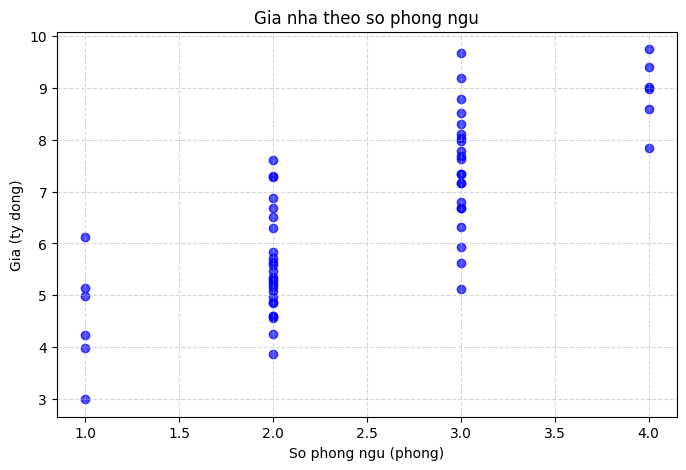

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import matplotlib.pyplot as plt
from google.colab import files

plt.figure(figsize=(8, 5))
plt.scatter(df["so_phong"], df["gia"], color="blue", alpha=0.7)
plt.title("Gia nha theo so phong ngu")
plt.xlabel("So phong ngu (phong)")
plt.ylabel("Gia (ty dong)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.savefig("bai2.png", dpi=150)
plt.show()
files.download("bai2.png")


###Bài 3

In [24]:
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"He so goc   w = {w:.6f}")
print(f"He so chan  b = {b:.6f}")
print()
print("Giai thich dau cua w:")
print("He so goc w mang dau am vi tuoi nha va gia nha co quan he ty le nghich.")
print("Khi tuoi nha tang them 1 nam (nha cu hon), gia ban trung binh cua can ho giam đi.")

He so goc   w = -0.037858
He so chan  b = 6.983593

Giai thich dau cua w:
He so goc w mang dau am vi tuoi nha va gia nha co quan he ty le nghich.
Khi tuoi nha tang them 1 nam (nha cu hon), gia ban trung binh cua can ho giam đi.


###Bài 4

In [25]:
X = df[["dien_tich", "so_phong"]]
y = df["gia"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R2 tren tap kiem tra (dien_tich + so_phong): {r2:.4f}")
print()
print("So sanh va danh gia:")
print(f"So voi R2 = 0.9622 cua mo hinh mot bien (dien_tich), chi so R2 moi dat {r2:.4f}.")
print("Viec them so_phong giup mo hinh tang nhe do chinh xac, tuy nhien muc tang không phai la qua lon vi dien_tich da giai thich phan lon bien thien cua gia.")

R2 tren tap kiem tra (dien_tich + so_phong): 0.9698

So sanh va danh gia:
So voi R2 = 0.9622 cua mo hinh mot bien (dien_tich), chi so R2 moi dat 0.9698.
Viec them so_phong giup mo hinh tang nhe do chinh xac, tuy nhien muc tang không phai la qua lon vi dien_tich da giai thich phan lon bien thien cua gia.


###Bài 5

In [27]:
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
n = len(x)

def chay_gradient_descent(toc_do_hoc, so_vong=200):
    w, b = 0.0, 0.0
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    mse = (((w * x + b) - y) ** 2).mean()
    return mse

mse_0001 = chay_gradient_descent(0.001)
mse_102 = chay_gradient_descent(1.02)

print(f"MSE o vong 200 voi toc_do_hoc = 0.001 : {mse_0001:.4f}")
print(f"MSE o vong 200 voi toc_do_hoc = 1.02  : {mse_102:.4e}")
print()
print("Giai thich vi sao hai con so khac nhau:")
print("1. Voi toc_do_hoc = 0.001 (qua nho): Thuat toan buoc di qua cham, sau 200 vong van chua kip do den day cua sai so (MSE con cao).")
print("2. Voi toc_do_hoc = 1.02 (qua lon): Thuat toan nhay qua xa qua day, khien sai so bi phan phan va tang vọt qua moi vong lặp.")

MSE o vong 200 voi toc_do_hoc = 0.001 : 20.2175
MSE o vong 200 voi toc_do_hoc = 1.02  : 2.9039e+08

Giai thich vi sao hai con so khac nhau:
1. Voi toc_do_hoc = 0.001 (qua nho): Thuat toan buoc di qua cham, sau 200 vong van chua kip do den day cua sai so (MSE con cao).
2. Voi toc_do_hoc = 1.02 (qua lon): Thuat toan nhay qua xa qua day, khien sai so bi phan phan va tang vọt qua moi vong lặp.


###Bài 6

In [30]:
W_CHUAN = 0.078367
B_CHUAN = 0.401752

def du_doan_gia(dien_tich):
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(f" {dien_tich} m2 nam ngoai khoang du lieu hoc (35.5 - 117.5 m2). Ket qua co the khong dang tin tin!")

    gia_du_doan = W_CHUAN * dien_tich + B_CHUAN
    return gia_du_doan

cac_muc_dt = [60, 80, 200]

print("Du Doan")
for dt in cac_muc_dt:
    gia = du_doan_gia(dt)
    print(f"Dien tich: {dt:3d} m2 -> Gia du doan: {gia:.3f} ty dong\n")

Du Doan
Dien tich:  60 m2 -> Gia du doan: 5.104 ty dong

Dien tich:  80 m2 -> Gia du doan: 6.671 ty dong

 200 m2 nam ngoai khoang du lieu hoc (35.5 - 117.5 m2). Ket qua co the khong dang tin tin!
Dien tich: 200 m2 -> Gia du doan: 16.075 ty dong

